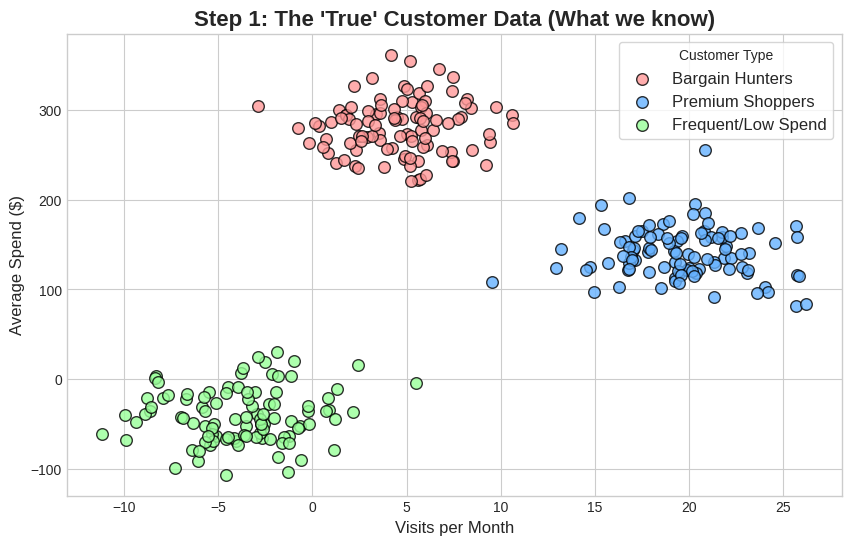

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=300, centers=3, cluster_std=1.5, random_state=42)

visits_per_month = X[:, 0] * 2 + 10
average_spend = X[:, 1] * 20 + 100

X_supermarket = np.column_stack((visits_per_month, average_spend))

plt.figure(figsize=(10, 6))
plt.style.use('seaborn-v0_8-whitegrid')

colors = ['#FF9999', '#66B2FF', '#99FF99']
labels = ['Bargain Hunters', 'Premium Shoppers', 'Frequent/Low Spend']

for i in range(3):
    plt.scatter(X_supermarket[y == i, 0], X_supermarket[y == i, 1],
                color=colors[i], label=labels[i], edgecolors='black', s=70, alpha=0.8)

plt.title("Step 1: The 'True' Customer Data (What we know)", fontsize=16, fontweight='bold')
plt.xlabel("Visits per Month", fontsize=12)
plt.ylabel("Average Spend ($)", fontsize=12)
plt.legend(title="Customer Type", fontsize=12, frameon=True)
plt.show()

Supervised Model Accuracy: 100.00%



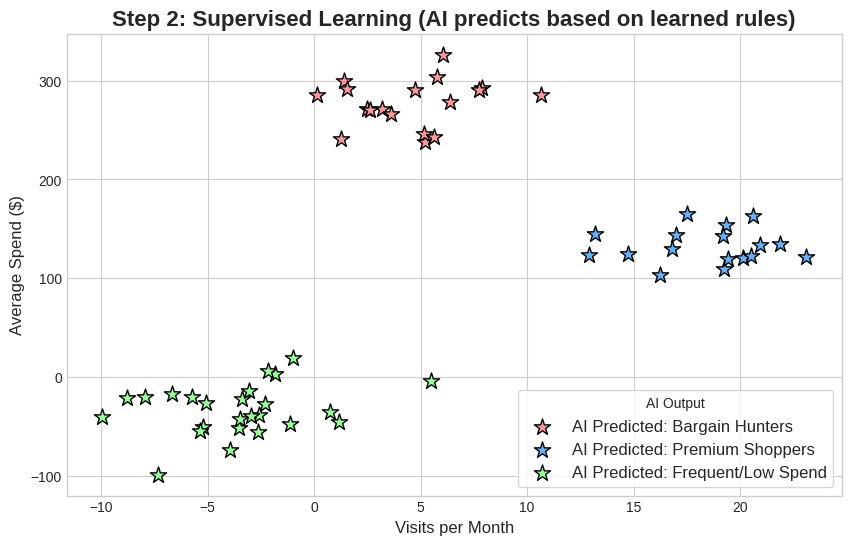

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(X_supermarket, y, test_size=0.2, random_state=42)

model_supervised = LogisticRegression(max_iter=1000)
model_supervised.fit(X_train, y_train)

predictions = model_supervised.predict(X_test)
print(f"Supervised Model Accuracy: {accuracy_score(y_test, predictions) * 100:.2f}%\n")

plt.figure(figsize=(10, 6))
plt.style.use('seaborn-v0_8-whitegrid')

for i in range(3):
    plt.scatter(X_test[predictions == i, 0], X_test[predictions == i, 1],
                color=colors[i], label=f'AI Predicted: {labels[i]}',
                edgecolors='black', s=150, marker='*')

plt.title("Step 2: Supervised Learning (AI predicts based on learned rules)", fontsize=16, fontweight='bold')
plt.xlabel("Visits per Month", fontsize=12)
plt.ylabel("Average Spend ($)", fontsize=12)
plt.legend(title="AI Output", fontsize=12, frameon=True)
plt.show()

In [ ]:
new_customer = [[25, 80]]
predicted_group = model_supervised.predict(new_customer)
print(f"The model predicts this is a: {predicted_group}")

The model predicts this is a: [1]


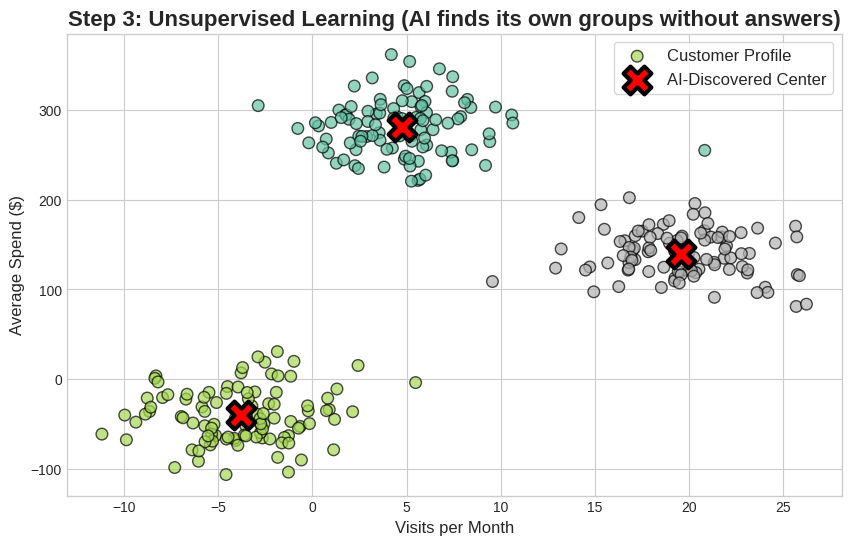

In [ ]:
from sklearn.cluster import KMeans

model_unsupervised = KMeans(n_clusters=3, random_state=42, n_init=10)

model_unsupervised.fit(X_supermarket)

discovered_groups = model_unsupervised.labels_
centers = model_unsupervised.cluster_centers_

plt.figure(figsize=(10, 6))
plt.style.use('seaborn-v0_8-whitegrid')

plt.scatter(X_supermarket[:, 0], X_supermarket[:, 1], c=discovered_groups, cmap='Set2',
            edgecolors='black', s=70, alpha=0.7, label='Customer Profile')

plt.scatter(centers[:, 0], centers[:, 1], color='red', marker='X', s=400,
            edgecolors='black', linewidth=3, label='AI-Discovered Center')

plt.title("Step 3: Unsupervised Learning (AI finds its own groups without answers)", fontsize=16, fontweight='bold')
plt.xlabel("Visits per Month", fontsize=12)
plt.ylabel("Average Spend ($)", fontsize=12)
plt.legend(fontsize=12, frameon=True)
plt.show()

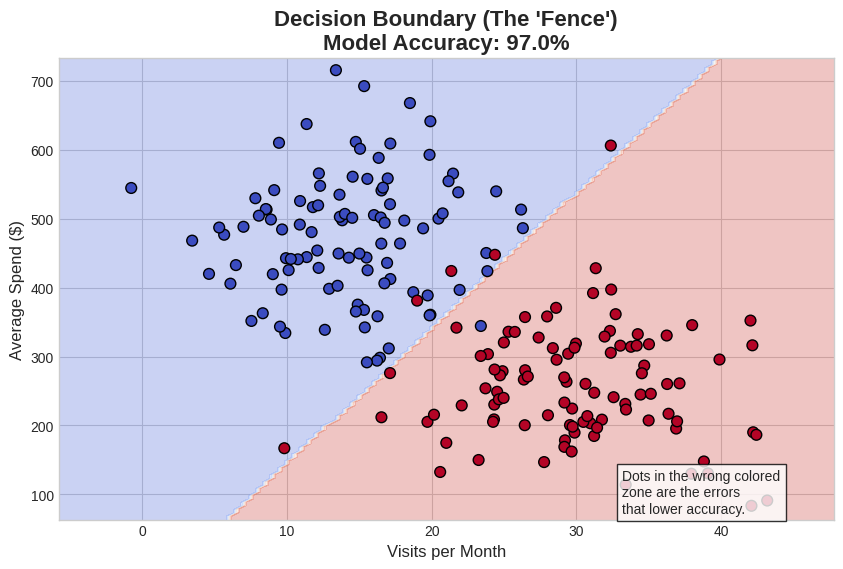

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_blobs
from sklearn.metrics import accuracy_score

X_binary, y_binary = make_blobs(n_samples=200, centers=2, cluster_std=3.0, random_state=42)

X_binary[:, 0] = X_binary[:, 0] * 2 + 20
X_binary[:, 1] = X_binary[:, 1] * 30 + 200

model_boundary = LogisticRegression()
model_boundary.fit(X_binary, y_binary)

predictions = model_boundary.predict(X_binary)
accuracy = accuracy_score(y_binary, predictions) * 100

plt.figure(figsize=(10, 6))
plt.style.use('seaborn-v0_8-whitegrid')

x_min, x_max = X_binary[:, 0].min() - 5, X_binary[:, 0].max() + 5
y_min, y_max = X_binary[:, 1].min() - 20, X_binary[:, 1].max() + 20
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.5), np.arange(y_min, y_max, 5))

Z = model_boundary.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')

plt.scatter(X_binary[:, 0], X_binary[:, 1], c=y_binary, cmap='coolwarm', edgecolors='black', s=60)

plt.title(f"Decision Boundary (The 'Fence')\nModel Accuracy: {accuracy:.1f}%", fontsize=16, fontweight='bold')
plt.xlabel("Visits per Month", fontsize=12)
plt.ylabel("Average Spend ($)", fontsize=12)

plt.text(x_max - 15, y_min + 10, "Dots in the wrong colored\nzone are the errors\nthat lower accuracy.",
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='black'))

plt.show()